# 04 - Linear Filters: Mean and Gaussian

A linear spatial filter combines neighboring samples with kernel coefficients. A normalized smoothing kernel has coefficients that sum to one, which preserves constant image regions.

In [1]:
from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_course_root() -> Path:
    """Locate the cloned course repository without a machine-specific path."""
    candidates = []
    configured = os.environ.get("VISION_ROBOTICA_REPO")
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    for candidate in candidates:
        if (candidate / "imagenes").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError(
        "Course repository not found. Run the notebook from the cloned repository root "
        "or define VISION_ROBOTICA_REPO."
    )

ROOT = find_course_root()
COURSE_IMAGES = ROOT / "imagenes"
STUDENT_IMAGES = ROOT / "student_work" / "imagenes"
STUDENT_IMAGES.mkdir(parents=True, exist_ok=True)

def load_rgb(filename: str) -> np.ndarray:
    path = COURSE_IMAGES / filename
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Official course image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Course root: {ROOT}")
print(f"Official images: {COURSE_IMAGES}")
print(f"Student images: {STUDENT_IMAGES}")

Course root: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica
Official images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\imagenes
Student images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\student_work\imagenes


Mean-kernel sum: 1.000000
Gaussian-kernel sum: 1.000000


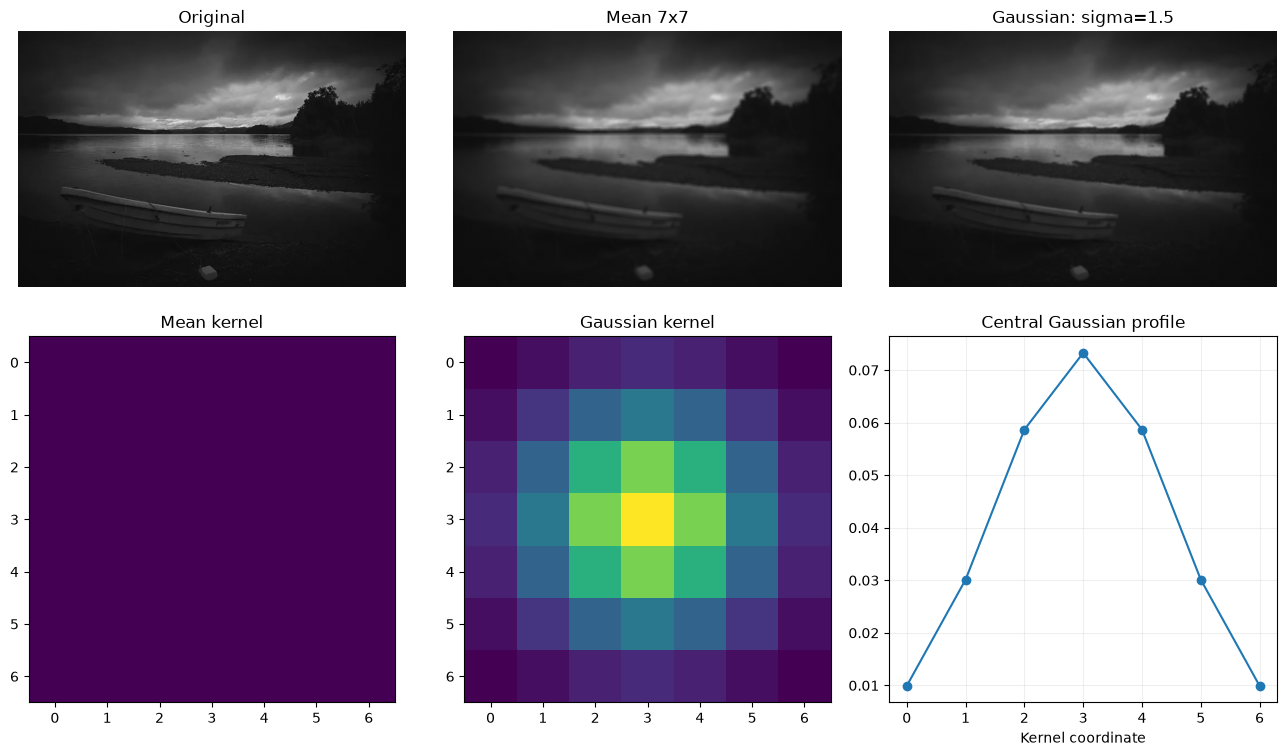

In [2]:
image_rgb = load_rgb("barco.png")
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

kernel_size = 7
mean_filtered = cv2.blur(gray, (kernel_size, kernel_size), borderType=cv2.BORDER_REFLECT_101)
gaussian_filtered = cv2.GaussianBlur(gray, (kernel_size, kernel_size), sigmaX=1.5, borderType=cv2.BORDER_REFLECT_101)

mean_kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / kernel_size**2
gaussian_1d = cv2.getGaussianKernel(kernel_size, 1.5)
gaussian_kernel = gaussian_1d @ gaussian_1d.T

print(f"Mean-kernel sum: {mean_kernel.sum():.6f}")
print(f"Gaussian-kernel sum: {gaussian_kernel.sum():.6f}")

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for axis, image, title in zip(
    axes[0], [gray, mean_filtered, gaussian_filtered],
    ["Original", f"Mean {kernel_size}x{kernel_size}", "Gaussian: sigma=1.5"],
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
axes[1, 0].imshow(mean_kernel, cmap="viridis")
axes[1, 0].set_title("Mean kernel")
axes[1, 1].imshow(gaussian_kernel, cmap="viridis")
axes[1, 1].set_title("Gaussian kernel")
axes[1, 2].plot(gaussian_kernel[kernel_size // 2], marker="o")
axes[1, 2].set_title("Central Gaussian profile")
axes[1, 2].set_xlabel("Kernel coordinate")
axes[1, 2].grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [3]:
def gradient_energy(image: np.ndarray) -> float:
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3)
    return float(np.mean(cv2.magnitude(gx, gy)))

baseline = gradient_energy(gray)
for name, image in {"Original": gray, "Mean": mean_filtered, "Gaussian": gaussian_filtered}.items():
    print(f"{name:8s}: intensity std={image.std():7.2f}, gradient retention={gradient_energy(image)/baseline:.3f}")

Original: intensity std=  38.77, gradient retention=1.000
Mean    : intensity std=  37.93, gradient retention=0.594
Gaussian: intensity std=  38.17, gradient retention=0.659


## Robotic interpretation

Smoothing may stabilize gradients and reduce false detections, but declining gradient retention indicates loss of edge evidence. Kernel size and Gaussian standard deviation must be selected for the expected feature scale and processing budget.